In [21]:
!pip freeze
!python --version

absl-py==2.4.0
albucore==0.0.24
albumentations==2.0.8
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.12.1
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
arrow==1.4.0
asttokens @ file:///home/conda/feedstock_root/build_artifacts/asttokens_1763409923949/work
async-lru==2.1.0
attrs==25.4.0
babel==2.18.0
beautifulsoup4==4.14.3
black==26.1.0
bleach==6.3.0
certifi==2026.1.4
cffi==2.0.0
charset-normalizer==3.4.4
cjm-pandas-utils==0.0.3
cjm-pil-utils==0.0.9
cjm-psl-utils==0.0.4
cjm-pytorch-utils==0.0.8
cjm-torchvision-tfms==0.0.26
click==8.3.1
cloudpickle==3.1.2
comm @ file:///home/conda/feedstock_root/build_artifacts/bld/rattler-build_comm_1753453984/work
contourpy==1.3.3
cuda-bindings==12.9.4
cuda-pathfinder==1.3.4
cycler==0.12.1
debugpy @ file:///home/conda/feedstock_root/build_artifacts/bld/rattler-build_debugpy_1769744978/work
decorator @ file:///home/conda/feedstock_root/build_artifacts/decorator_1740384970518/work
defusedxml==0.7.1
detectron2 @ git+

In [22]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [23]:
import datetime
import os
import json
import re
from typing import Any
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [24]:


ROOT = Path("checkpoints/semantic/train/[20260311-221248]_segformer_trains")
FULL_TRAIN_REAL = 100 
MONITOR_COL = "metrics/mean_iou"   # primary metric
CONVERGENCE_RATIO = 0.95           # 95% of best metric

summary_rows = []
full_rows = []

# _subset_re = re.compile(r"\[subset-(?P<pct>\d+(?:\.\d+)?)\]")
# def extract_size_from_name(run_name: str, full_size: int = FULL_TRAIN_REAL) -> int:
#     """
#     Parse subset fraction from folder name and return number of real training images.
#     Example:
#       '...-finetune[subset-1.0]-...' -> 100
#       '...-finetune[subset-0.25]-...' -> 25
#     """
#     m = _subset_re.search(run_name)
#     if not m:
#         raise ValueError(f"Could not parse subset fraction from run name: {run_name}")
#     frac = float(m.group("pct"))
#     # convert fraction -> count; round to nearest int (or use floor if you prefer)
#     return int(round(frac * full_size))

_subset_re = re.compile(r"\[subset-(?P<n>\d+)\]")
def extract_real_count(run_name: str) -> int:
    m = _subset_re.search(run_name)
    if not m:
        raise ValueError(f"Could not parse subset size from: {run_name}")
    return int(m.group("n"))

def load_per_class_at_epoch(run_dir: Path, epoch: int) -> tuple[dict[int, float] | None, dict[int, float] | None]:
    p = run_dir / "per_class" / f"epoch_{epoch:03d}.json"
    if not p.exists():
        return None, None

    with p.open("r", encoding="utf-8") as f:
        data: dict[str, Any] = json.load(f)

    class_iou_raw = data.get("class_iou")
    class_dice_raw = data.get("class_dice")

    def to_int_keyed(d):
        if not isinstance(d, dict):
            return None
        out = {}
        for k, v in d.items():
            try:
                out[int(k)] = float(v)
            except Exception:
                pass
        return out or None

    return to_int_keyed(class_iou_raw), to_int_keyed(class_dice_raw)

for run_dir in ROOT.iterdir():
    if not run_dir.is_dir():
        continue

    print(str(run_dir))

    csv_path = run_dir / "results.csv"
    if not csv_path.exists():
        continue

    df = pd.read_csv(csv_path)

    real_count = extract_real_count(run_dir.name)

    best_idx = df["metrics/mean_iou"].idxmax()
    best_row = df.loc[best_idx]
    best_value = best_row[MONITOR_COL]
    best_epoch = int(best_row["epoch"])

    class_iou, class_dice = load_per_class_at_epoch(run_dir, best_epoch)

    

    # maximum generalisability gap = best_val/loss - best_train/loss
    df["gen_gap"] = df["val/loss"] - df["train/loss"]
    max_gap = df["gen_gap"].max()

    total_time = df["time/epoch"].sum()

    threshold = CONVERGENCE_RATIO * best_value
    conv_epoch = df[df[MONITOR_COL] >= threshold]["epoch"].iloc[0]

    summary_rows.append({
        "run": run_dir.name,
        "real_count": real_count,
        "best_epoch": best_epoch,
        "best_iou": best_value,
        "best_dice": best_row["metrics/mean_dice"],
        "class_iou": class_iou,
        "class_dice": class_dice,
        "best_overall_acc": best_row["metrics/overall_acc"],
        "val_loss_best": best_row["val/loss"],
        "convergence_epoch": conv_epoch,
        "max_generalisation_gap": max_gap,
        "total_training_time": total_time,
    })

    tmp = df.copy()
    tmp["run"] = run_dir.name
    tmp["real_count"] = real_count
    full_rows.append(tmp)

full = pd.concat(full_rows, ignore_index=True).sort_values(["real_count", "epoch"]).reset_index(drop=True)

summary = pd.DataFrame(summary_rows)
summary = summary.sort_values("real_count").reset_index(drop=True)
summary["delta_iou"] = summary["best_iou"].diff()
# Expand IoU
iou_wide = summary["class_iou"].apply(lambda d: d or {}).apply(pd.Series)
iou_wide = iou_wide.add_prefix("iou_c")

# Expand Dice
dice_wide = summary["class_dice"].apply(lambda d: d or {}).apply(pd.Series)
dice_wide = dice_wide.add_prefix("dice_c")

summary_wide = pd.concat([summary.drop(columns=["class_iou", "class_dice"]), iou_wide, dice_wide], axis=1)


checkpoints/semantic/train/[20260311-221248]_segformer_trains/train[subset-300]-segformer_mit_b2_bean_sdxl_semantic_turntable
checkpoints/semantic/train/[20260311-221248]_segformer_trains/train[subset-700]-segformer_mit_b2_bean_sdxl_semantic_turntable
checkpoints/semantic/train/[20260311-221248]_segformer_trains/train[subset-2000]-segformer_mit_b2_bean_sdxl_semantic_turntable
checkpoints/semantic/train/[20260311-221248]_segformer_trains/train[subset-1800]-segformer_mit_b2_bean_sdxl_semantic_turntable
checkpoints/semantic/train/[20260311-221248]_segformer_trains/train[subset-1400]-segformer_mit_b2_bean_sdxl_semantic_turntable
checkpoints/semantic/train/[20260311-221248]_segformer_trains/train[subset-1000]-segformer_mit_b2_bean_sdxl_semantic_turntable
checkpoints/semantic/train/[20260311-221248]_segformer_trains/train[subset-1700]-segformer_mit_b2_bean_sdxl_semantic_turntable
checkpoints/semantic/train/[20260311-221248]_segformer_trains/train[subset-1300]-segformer_mit_b2_bean_sdxl_seman

In [25]:
np.shape(full_rows)

(20, 100, 15)

In [26]:
summary

,run,real_count,best_epoch,best_iou,best_dice,class_iou,class_dice,best_overall_acc,val_loss_best,convergence_epoch,max_generalisation_gap,total_training_time,delta_iou
0,train[subset-100]-segformer_mit_b2_bean_sdxl_s...,100,26,0.583436,0.695134,"{0: 0.982337551128432, 1: 0.7343731778095558, ...","{0: 0.9910900901506337, 1: 0.846845635305592, ...",0.974635,0.220388,10.0,0.202771,583.111847,NaN
1,train[subset-200]-segformer_mit_b2_bean_sdxl_s...,200,24,0.623901,0.735159,"{0: 0.9886649151013236, 1: 0.7693921977377066,...","{0: 0.9943001534282617, 1: 0.8696683513371757,...",0.979622,0.194233,10.0,0.177867,857.668927,0.040465
2,train[subset-300]-segformer_mit_b2_bean_sdxl_s...,300,28,0.605903,0.715841,"{0: 0.9838837741446156, 1: 0.7737056747316252,...","{0: 0.9918764263988533, 1: 0.8724172062523199,...",0.976957,0.203430,11.0,0.195247,1122.406113,-0.017998
3,train[subset-400]-segformer_mit_b2_bean_sdxl_s...,400,12,0.615990,0.726034,"{0: 0.9867841371847337, 1: 0.7752633748575384,...","{0: 0.9933481133818629, 1: 0.873406600775225, ...",0.978839,0.194263,2.0,0.193949,1389.901333,0.010087
4,train[subset-500]-segformer_mit_b2_bean_sdxl_s...,500,15,0.684605,0.786151,"{0: 0.9895598115108987, 1: 0.8024066039123401,...","{0: 0.9947525133807498, 1: 0.8903724633172339,...",0.982872,0.164976,4.0,0.149818,1627.321762,0.068615
5,train[subset-600]-segformer_mit_b2_bean_sdxl_s...,600,25,0.662873,0.770053,"{0: 0.9888396225907327, 1: 0.790059698345003, ...","{0: 0.9943884980556001, 1: 0.8827188267245517,...",0.981590,0.176853,14.0,0.188688,1906.976241,-0.021732
6,train[subset-700]-segformer_mit_b2_bean_sdxl_s...,700,31,0.587348,0.695645,"{0: 0.9860616777358722, 1: 0.7599175222714907,...","{0: 0.9929819287988993, 1: 0.8635831084750837,...",0.976931,0.215966,1.0,0.209023,2162.236349,-0.075525
7,train[subset-800]-segformer_mit_b2_bean_sdxl_s...,800,25,0.648400,0.756350,"{0: 0.9871689502817499, 1: 0.786312462563302, ...","{0: 0.9935430504203325, 1: 0.8803750508855192,...",0.980460,0.181277,11.0,0.198378,2436.008764,0.061052
8,train[subset-900]-segformer_mit_b2_bean_sdxl_s...,900,1,0.656711,0.765475,"{0: 0.984289669683112, 1: 0.7236474821212499, ...","{0: 0.9920826426922855, 1: 0.8396699320799343,...",0.977720,0.273727,1.0,0.185858,2689.361050,0.008311
9,train[subset-1000]-segformer_mit_b2_bean_sdxl_...,1000,4,0.599322,0.708909,"{0: 0.9864115100650218, 1: 0.7665007730962505,...","{0: 0.9931592774880098, 1: 0.8678182141440666,...",0.977537,0.213584,1.0,0.197678,2976.895911,-0.057389


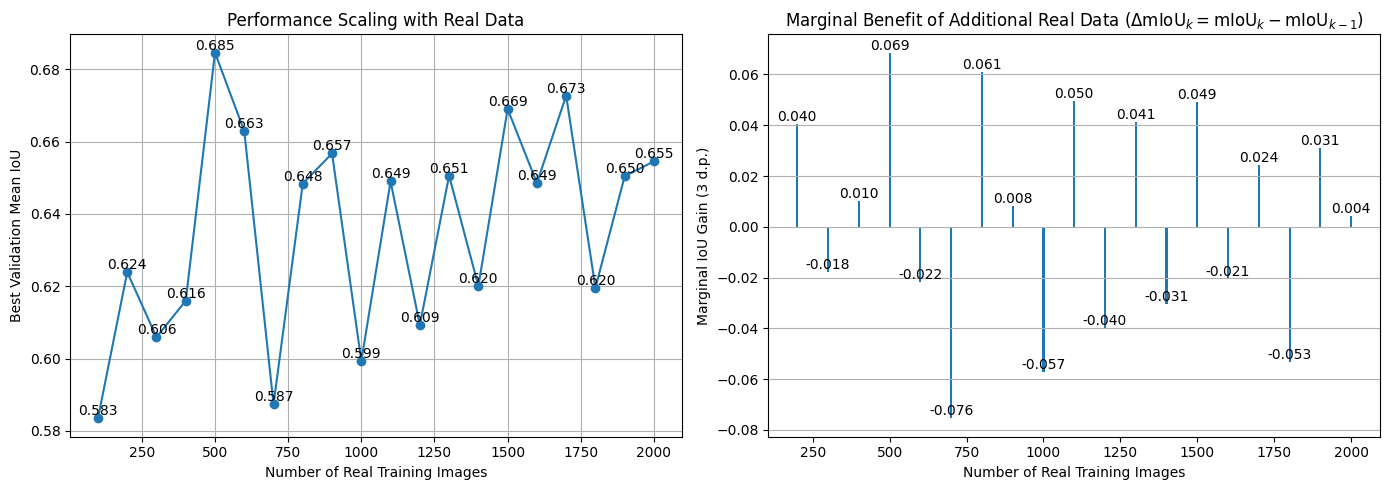

In [27]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Left plot: Best Segm AP vs Real Data Size ---
x = summary["real_count"]
y = summary["best_iou"]

ax1.plot(x, y, marker="o")
for xi, yi in zip(x, y):
    ax1.text(xi, yi, f"{yi:.3f}", ha="center", va="bottom")


ax1.set_xlabel("Number of Real Training Images")
ax1.set_ylabel("Best Validation Mean IoU")
ax1.set_title("Performance Scaling with Real Data")
# ax1.set_xticks(np.arange(0, 100, step=10))
ax1.grid(True)

# --- Right plot: Marginal Gain in Best Segm AP ---
bars = ax2.bar(summary["real_count"][1:], summary["delta_iou"][1:], width=7)

for bar in bars:
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )

ax2.set_xlabel("Number of Real Training Images")
# ax2.set_xticks(np.arange(10, 110, step=10))
ax2.set_ylabel("Marginal IoU Gain (3 d.p.)")
ax2.set_title(r"Marginal Benefit of Additional Real Data ($\Delta \text{mIoU}_k = \text{mIoU}_k - \text{mIoU}_{k-1}$)")

ax2.grid(True, axis="y", which="both")

plt.tight_layout()
plt.show()

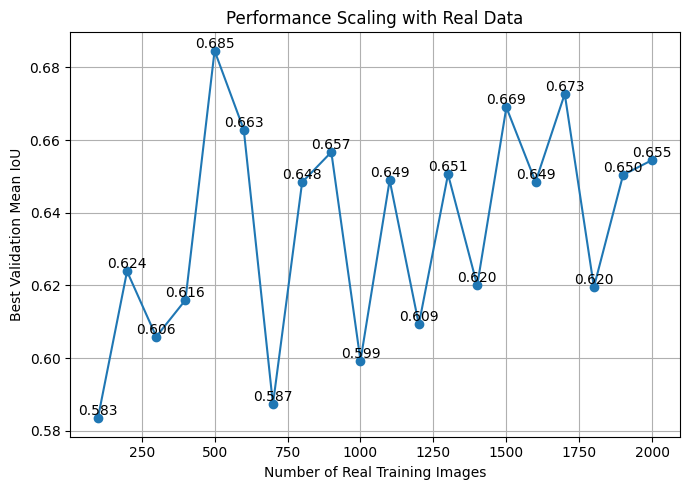

In [28]:
x = summary["real_count"]
y = summary["best_iou"]

plt.figure(figsize=(7,5))
plt.plot(x, y, marker="o")

# Add value labels
for xi, yi in zip(x, y):
    plt.text(xi, yi, f'{yi:.3f}',
             ha='center',
             va='bottom')

plt.xlabel("Number of Real Training Images")
# plt.xticks(np.arange(0, 100, step=10))
plt.ylabel("Best Validation Mean IoU")
plt.title("Performance Scaling with Real Data")
plt.grid(True)
plt.tight_layout()
plt.show()

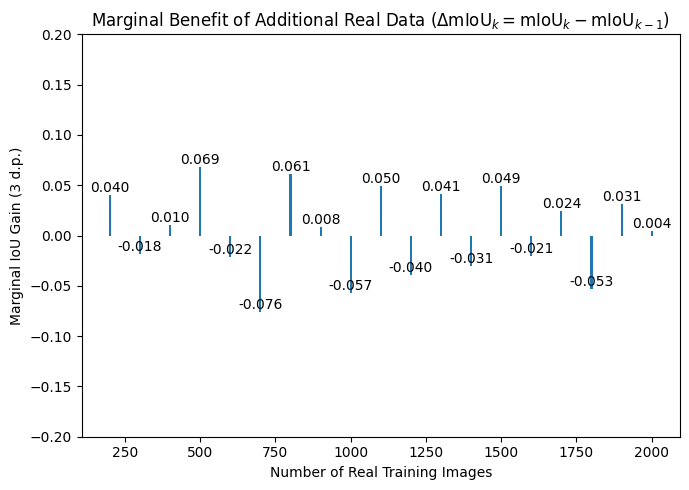

In [40]:
plt.figure(figsize=(7,5))
bars = plt.bar(summary["real_count"][1:], summary["delta_iou"][1:], width=7)
plt.xlabel("Number of Real Training Images")
# plt.xticks(np.arange(10, 110, step=10))
plt.ylabel("Marginal IoU Gain (3 d.p.)")
plt.ylim((-0.2, 0.2))
plt.title(r"Marginal Benefit of Additional Real Data ($\Delta \text{mIoU}_k = \text{mIoU}_k - \text{mIoU}_{k-1}$)")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.3f}', ha='center',va='bottom')
plt.tight_layout()
plt.show()


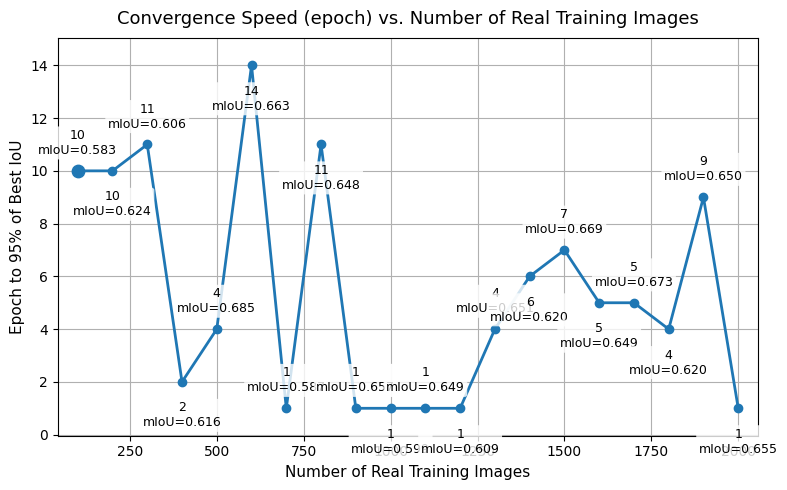

In [30]:
# x = summary["real_count"]
# y = summary["convergence_epoch"].astype(dtype=np.uint)

# plt.figure(figsize=(10,5))
# plt.plot(x, y, marker="o")

# for i, (xi, yi) in enumerate(zip(x, y)):
#     plt.text(xi, yi, f'{yi} (mIoU: {summary["best_iou"][i]:.3f})',
#              ha='center',
#              va='bottom')
    
# plt.xlabel("Number of Real Training Images")
# plt.xticks(np.arange(0, 110, step=10))
# plt.ylabel("Epoch to 95% of Best IoU")
# plt.title("Convergence Speed")
# plt.tight_layout()
# plt.show()
import numpy as np
import matplotlib.pyplot as plt

x = summary["real_count"].to_numpy()
y = summary["convergence_epoch"].astype(np.uint).to_numpy()
miou = summary["best_iou"].to_numpy()

fig, ax = plt.subplots(figsize=(8, 5))

# Main line
ax.plot(x, y, marker="o", linewidth=2, markersize=6)

# Optional: highlight the baseline (x=0) point
if len(x) > 0:
    ax.scatter([x[0]], [y[0]], s=80, zorder=3)

# Annotate points with alternating offsets to reduce overlap
for i, (xi, yi, m) in enumerate(zip(x, y, miou)):
    # Alternate annotation positions (up/down) for readability
    dy = 10 if i % 2 == 0 else -14
    va = "bottom" if dy > 0 else "top"
    
    ax.annotate(
        f"{int(yi)}\nmIoU={m:.3f}",
        (xi, yi),
        xytext=(0, dy),
        textcoords="offset points",
        ha="center",
        va=va,
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8)
    )

# Axes formatting
ax.set_xlabel("Number of Real Training Images", fontsize=11)
ax.set_ylabel("Epoch to 95% of Best IoU", fontsize=11)
ax.set_title("Convergence Speed (epoch) vs. Number of Real Training Images", fontsize=13, pad=10)

# ax.set_xticks(np.arange(0, max(x) + 10, 10))
ax.grid(True) #  linestyle="--", alpha=0.35

# Add a little padding around data limits
ax.margins(x=0.03, y=0.08)

plt.tight_layout()
plt.show()

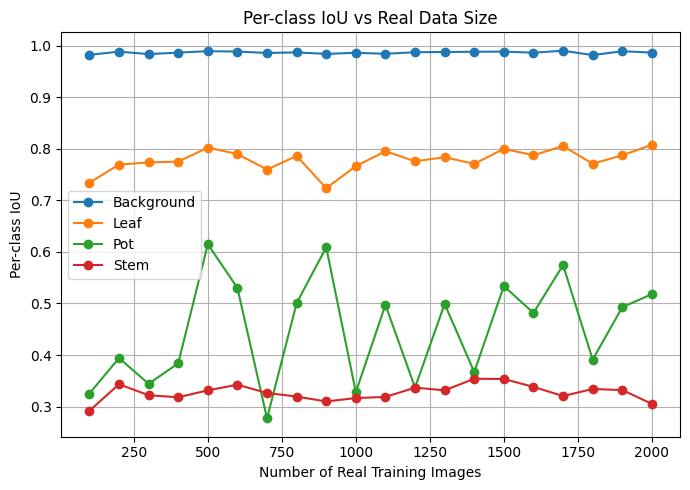

In [31]:
import matplotlib.pyplot as plt
import numpy as np

x = summary_wide["real_count"].values
iou_cols = [c for c in summary_wide.columns if c.startswith("iou_c")]
plt.figure(figsize=(7,5))
for c in iou_cols:
    plt.plot(x, summary_wide[c].values, marker="o", label=c)
plt.xlabel("Number of Real Training Images")
plt.ylabel("Per-class IoU")
plt.title("Per-class IoU vs Real Data Size")
# plt.xticks(np.arange(0, 110, 10))
plt.grid(True)
plt.legend(labels=["Background", "Leaf", "Pot", "Stem"])
plt.tight_layout()
plt.show()

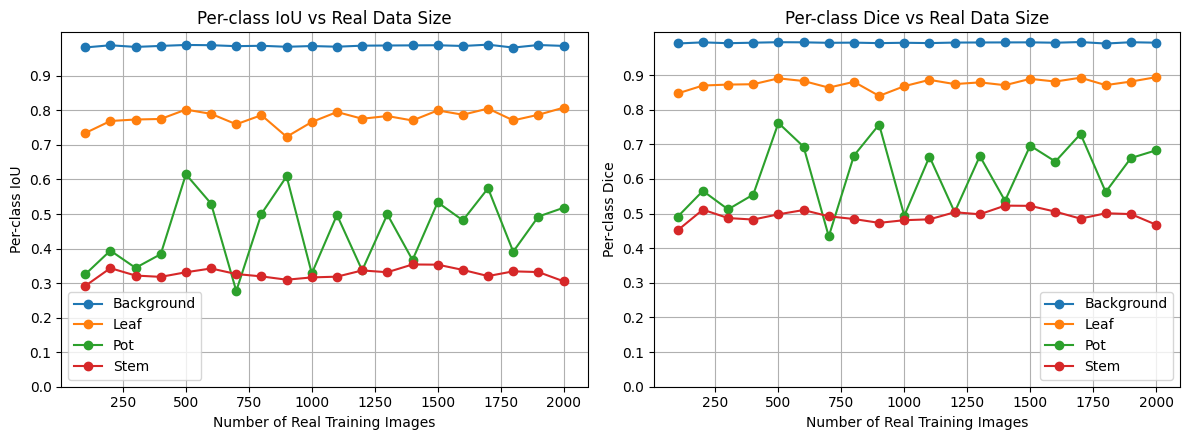

In [32]:

x = summary_wide["real_count"].values
iou_cols = [c for c in summary_wide.columns if c.startswith("iou_c")]
dice_cols = [c for c in summary_wide.columns if c.startswith("dice_c")]

# Create subplots (2 rows, 1 column) with shared x-axis
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)

# --- Top subplot: IoU ---
for c in iou_cols:
    axes[0].plot(x, summary_wide[c].values, marker="o", label=c)
axes[0].set_ylabel("Per-class IoU")
axes[0].set_yticks(np.arange(0.0, 1.0, 0.1))
axes[0].set_xlabel("Number of Real Training Images")
axes[0].set_title("Per-class IoU vs Real Data Size")
axes[0].grid(True)
axes[0].legend(labels=["Background", "Leaf", "Pot", "Stem"])

# --- Bottom subplot: Dice ---
for c in dice_cols:
    axes[1].plot(x, summary_wide[c].values, marker="o", label=c)
axes[1].set_xlabel("Number of Real Training Images")
axes[1].set_ylabel("Per-class Dice")
axes[1].set_yticks(np.arange(0.0, 1.0, 0.1))
axes[1].set_title("Per-class Dice vs Real Data Size")
# axes[1].set_xticks(np.arange(0, 110, 10))
axes[1].grid(True)
axes[1].legend(labels=["Background", "Leaf", "Pot", "Stem"], loc="lower right")

plt.tight_layout()
plt.show()

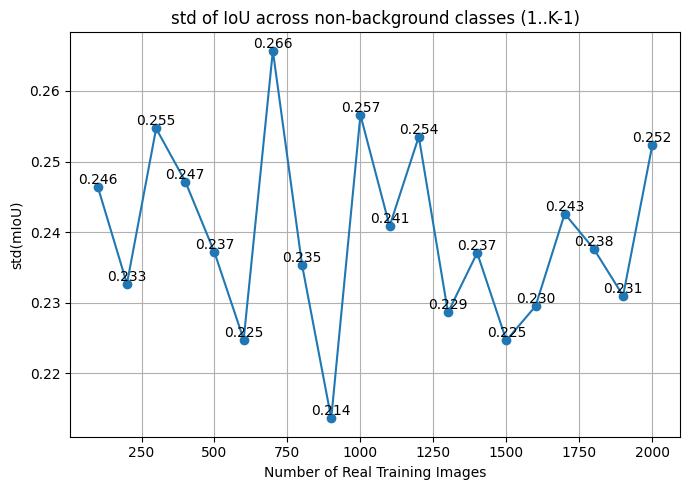

In [41]:
# example: std of IoU across non-background classes (1..K-1)
non_bg = [c for c in iou_cols if c != "iou_c0"]
summary_wide["iou_std_nonbg"] = summary_wide[non_bg].std(axis=1)

x = summary_wide["real_count"]
y = summary_wide["iou_std_nonbg"]

plt.figure(figsize=(7,5))
plt.plot(x, y, marker="o")

for xi, yi in zip(x, y):
    plt.text(xi, yi, f'{yi:.3f}',
             ha='center',
             va='bottom')

plt.xlabel("Number of Real Training Images")
# plt.xticks(np.arange(0,110,step=10))
plt.ylabel("std(mIoU)")
plt.title("std of IoU across non-background classes (1..K-1)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [34]:
full.columns

Index(['epoch', 'train/loss', 'val/loss', 'metrics/mean_iou',
       'metrics/mean_dice', 'metrics/overall_acc', 'metrics/mean_acc',
       'metrics/freqw_acc', 'lr', 'time/train', 'time/val', 'time/epoch',
       'gen_gap', 'run', 'real_count'],
      dtype='str')

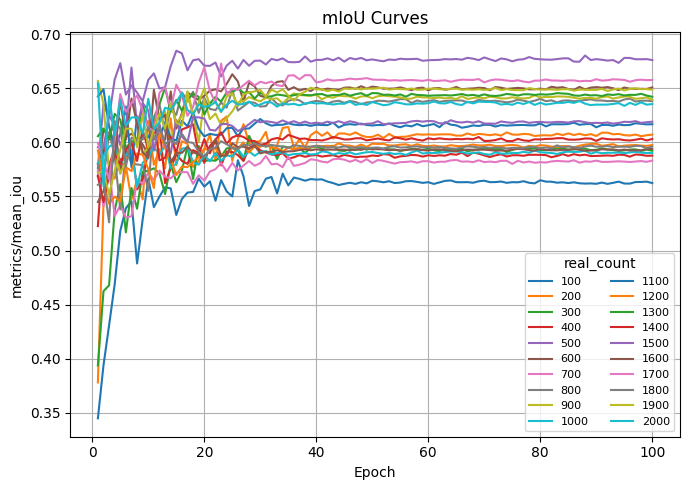

In [35]:
plt.figure(figsize=(7,5))
for rc, g in full.groupby("real_count"):
    plt.plot(g["epoch"], g["metrics/mean_iou"], label=str(rc))
plt.xlabel("Epoch")
plt.ylabel("metrics/mean_iou")
plt.title("mIoU Curves")
plt.grid(True)
plt.legend(title="real_count", ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

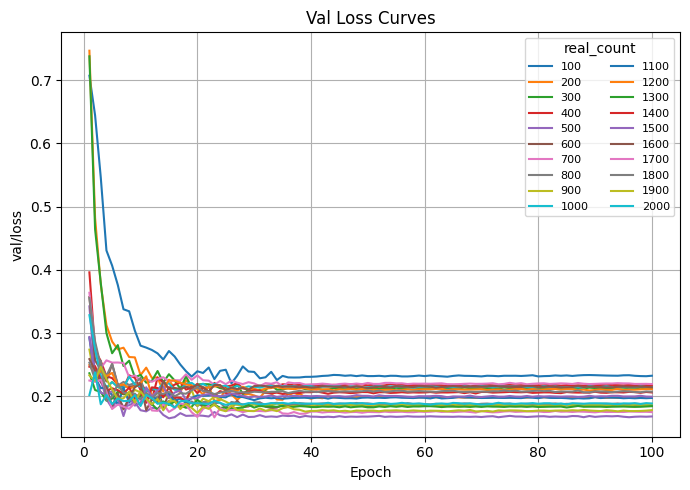

In [36]:
plt.figure(figsize=(7,5))
for rc, g in full.groupby("real_count"):
    plt.plot(g["epoch"], g["val/loss"], label=str(rc))
plt.xlabel("Epoch")
plt.ylabel("val/loss")
plt.title("Val Loss Curves")
plt.grid(True)
plt.legend(title="real_count", ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

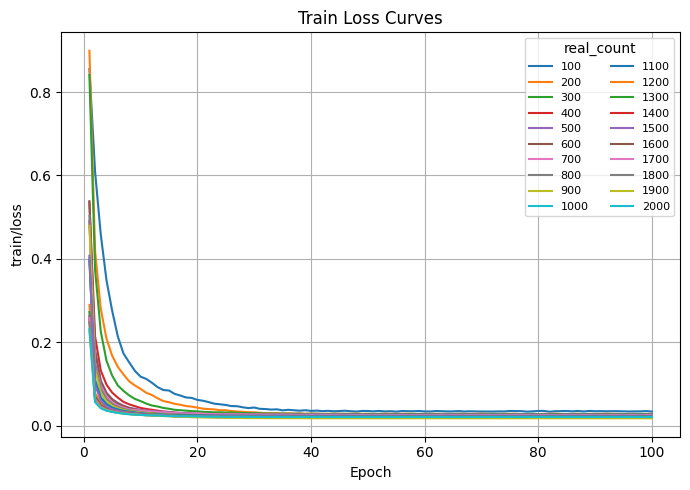

In [37]:
plt.figure(figsize=(7,5))
for rc, g in full.groupby("real_count"):
    plt.plot(g["epoch"], g["train/loss"], label=str(rc))
plt.xlabel("Epoch")
plt.ylabel("train/loss")
plt.title("Train Loss Curves")
plt.grid(True)
plt.legend(title="real_count", ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

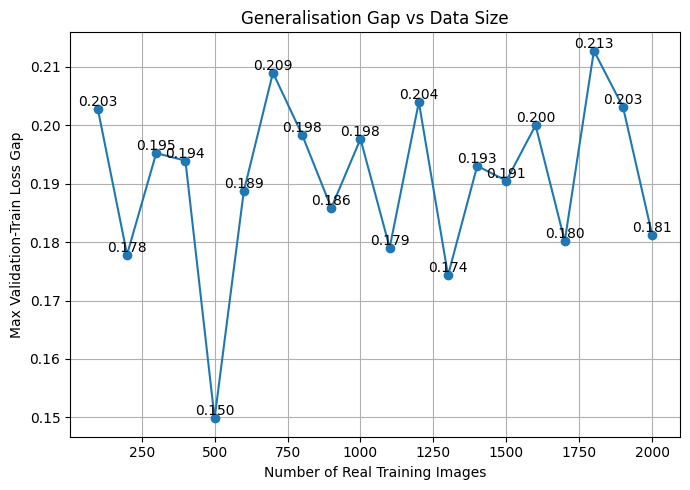

In [38]:
x = summary["real_count"]
y = summary["max_generalisation_gap"]

plt.figure(figsize=(7,5))
plt.plot(x, y, marker="o")

for xi, yi in zip(x, y):
    plt.text(xi, yi, f'{yi:.3f}',
             ha='center',
             va='bottom')

plt.xlabel("Number of Real Training Images")
plt.ylabel("Max Validation-Train Loss Gap")
plt.title("Generalisation Gap vs Data Size")
plt.tight_layout()
plt.grid(True)
plt.show()

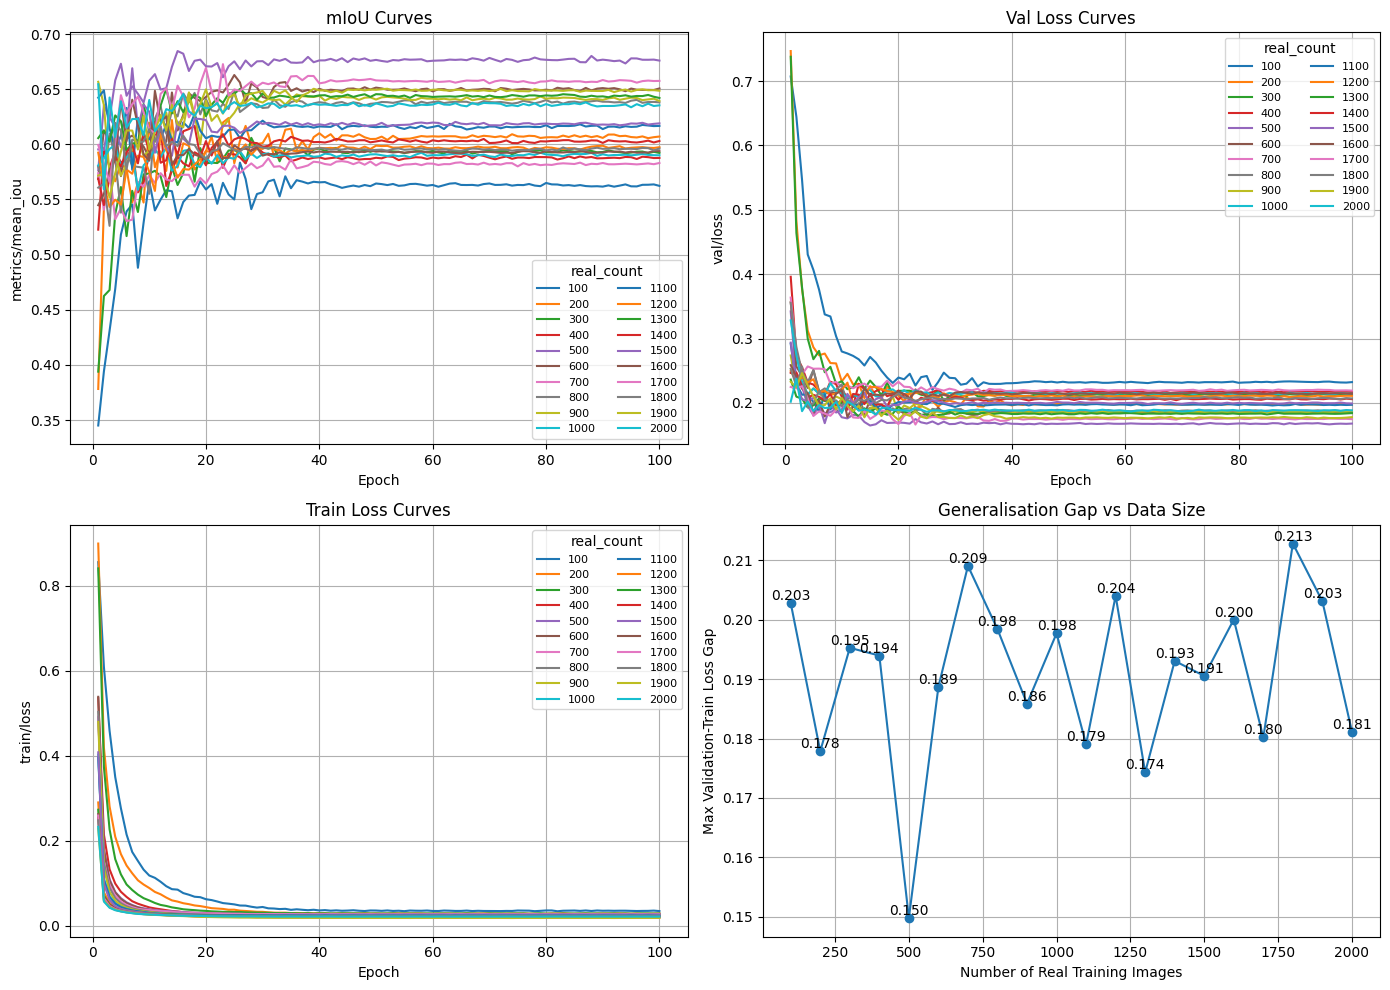

In [39]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
(ax1, ax2), (ax3, ax4) = axes

# 1) mIoU curves
for rc, g in full.groupby("real_count"):
    ax1.plot(g["epoch"], g["metrics/mean_iou"], label=str(rc))
ax1.set_xlabel("Epoch")
ax1.set_ylabel("metrics/mean_iou")
ax1.set_title("mIoU Curves")
ax1.grid(True)
ax1.legend(title="real_count", ncol=2, fontsize=8)

# 2) Val loss curves
for rc, g in full.groupby("real_count"):
    ax2.plot(g["epoch"], g["val/loss"], label=str(rc))
ax2.set_xlabel("Epoch")
ax2.set_ylabel("val/loss")
ax2.set_title("Val Loss Curves")
ax2.grid(True)
ax2.legend(title="real_count", ncol=2, fontsize=8)

# 3) Train loss curves
for rc, g in full.groupby("real_count"):
    ax3.plot(g["epoch"], g["train/loss"], label=str(rc))
ax3.set_xlabel("Epoch")
ax3.set_ylabel("train/loss")
ax3.set_title("Train Loss Curves")
ax3.grid(True)
ax3.legend(title="real_count", ncol=2, fontsize=8)

# 4) Generalisation gap vs data size
x = summary["real_count"]
y = summary["max_generalisation_gap"]

ax4.plot(x, y, marker="o")
for xi, yi in zip(x, y):
    ax4.text(xi, yi, f"{yi:.3f}", ha="center", va="bottom")
ax4.set_xlabel("Number of Real Training Images")
# ax4.set_xticks(np.arange(0,110,10))
ax4.set_ylabel("Max Validation-Train Loss Gap")
# ax4.set_yticks(np.arange(0.0, 1.1, 0.1))
ax4.set_title("Generalisation Gap vs Data Size")
ax4.grid(True)

plt.tight_layout()
plt.show()